# 03 Graph: position in the network, neighbours, short loops

**Training window only (Sep 1-6)** for all analysis here. Test graph features are built by
`python -m src.graph_features` but not looked at until Phase 5.

Phase 2 judged each account alone. Mules sit in **chains**, so this phase asks: *who does the account deal with,
and what do they look like?*

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.load import load_config, window_bounds
from src.graph_features import load_edges
from src.rules import fire_rules

pd.set_option("display.width", 200)
cfg = load_config()
start, end = window_bounds(cfg, "train")
fx = pd.read_csv("data/processed/fx_rates.csv")
feats = pd.read_parquet("data/processed/features_train.parquet")
graph = pd.read_parquet("data/processed/graph_features_train.parquet")
labels = pd.read_parquet("data/processed/labels_train.parquet")
d = graph.merge(labels[["account_id", "is_mule", "is_grey"]], on="account_id").merge(feats, on="account_id")
edges = load_edges(cfg["data"]["transactions_parquet"], start, end, fx)
base_rate = d.is_mule.mean()

## 1. The graph

In [2]:
print(f"accounts in graph: {pd.concat([edges.src, edges.dst]).nunique():,}")
print(f"edges (distinct sender -> receiver pairs): {len(edges):,}")
print(f"transfers collapsed into those edges: {edges.n_transfers.sum():,} (avg {edges.n_transfers.mean():.1f} per pair)")
print(f"accounts with only self-transfers (not in graph): {(d.in_count_per_day + d.out_count_per_day == 0).sum():,}")

accounts in graph: 408,244
edges (distinct sender -> receiver pairs): 573,336
transfers collapsed into those edges: 2,696,535 (avg 4.7 per pair)
accounts with only self-transfers (not in graph): 104,663


## 2. Why in/out/weighted degree are not added again
In-degree (number of distinct senders) is exactly Phase 2's `fan_in`. Checked here rather than assumed:

In [3]:
days = (pd.Timestamp(end) - pd.Timestamp(start)).days
in_deg = edges.groupby("dst").size()
out_deg = edges.groupby("src").size()
f = feats.set_index("account_id")
print("in-degree == fan_in:  ", np.allclose(in_deg, (f.loc[in_deg.index, "fan_in_per_day"] * days).round()))
print("out-degree == fan_out:", np.allclose(out_deg, (f.loc[out_deg.index, "fan_out_per_day"] * days).round()))

in-degree == fan_in:   True


out-degree == fan_out: True


## 3. How mules compare
Groups: **mule**, **grey** (touched laundering money but not pass-through), **clean two-way** (receives and sends), **clean other**.
- `pagerank_scaled`: PageRank x number of accounts, so the average is 1 in both train and test.
- `senders_pass_through_share` / `receivers_pass_through_share`: share of an account's counterparties that fire R1 (neighbours' behaviour, never their labels).
- `short_cycles_per_day`: loops of 2-4 hops the account is part of, searched only around R1-R4-flagged accounts, giant hubs excluded.

In [4]:
two_way = (d.in_count_per_day > 0) & (d.out_count_per_day > 0)
group = np.select([d.is_mule == 1, d.is_grey == 1, two_way], ["mule", "grey", "clean_two_way"], "clean_other")
cols = ["pagerank_scaled", "senders_pass_through_share", "receivers_pass_through_share", "short_cycles_per_day"]
pd.concat({"median": d[cols].groupby(group).median().T,
           "share with value > 0": (d[cols] > 0).groupby(group).mean().T}, axis=1).round(3)

median                             share with value > 0                            
                             clean_other clean_two_way   grey   mule          clean_other clean_two_way   grey   mule
pagerank_scaled                    0.521         0.903  1.008  1.241                0.709         1.000  1.000  1.000
senders_pass_through_share         0.000         0.000  0.000  0.000                0.017         0.051  0.053  0.153
receivers_pass_through_share       0.000         0.000  0.000  0.000                0.005         0.057  0.050  0.135
short_cycles_per_day               0.000         0.000  0.000  0.000                0.000         0.007  0.032  0.068

## 4. Graph signals vs the best rules (lift = precision / base rate)

In [5]:
fired = fire_rules(feats, cfg["rules"]).set_index(feats["account_id"]).loc[d.account_id].reset_index(drop=True)
signals = {
    "Rule R1 rapid pass-through": fired["R1_RAPID_PASS_THROUGH"],
    "Rule R4 new and bursty": fired["R4_NEW_AND_BURSTY"],
    "PageRank in top 1%": d.pagerank_scaled >= d.pagerank_scaled.quantile(0.99),
    "Some senders are pass-through": d.senders_pass_through_share > 0,
    "Some receivers are pass-through": d.receivers_pass_through_share > 0,
    "Part of a short loop": d.short_cycles_per_day > 0,
    "Pass-through neighbours on both sides": (d.senders_pass_through_share > 0) & (d.receivers_pass_through_share > 0),
}
rows = []
for name, m in signals.items():
    m = m.values
    p = d.is_mule[m].mean()
    rows.append(dict(signal=name, flagged=int(m.sum()), mules=int(d.is_mule[m].sum()), grey=int(d.is_grey[m].sum()),
                     precision_pct=round(100 * p, 2), recall_pct=round(100 * d.is_mule[m].sum() / d.is_mule.sum(), 1),
                     lift=round(p / base_rate, 1)))
lift_table = pd.DataFrame(rows)
lift_table

,signal,flagged,mules,grey,precision_pct,recall_pct,lift
0,Rule R1 rapid pass-through,5683,62,58,1.09,18.2,16.5
1,Rule R4 new and bursty,866,10,63,1.15,2.9,17.4
2,PageRank in top 1%,5130,22,329,0.43,6.5,6.5
3,Some senders are pass-through,13798,52,166,0.38,15.3,5.7
4,Some receivers are pass-through,10694,46,156,0.43,13.5,6.5
5,Part of a short loop,1162,23,101,1.98,6.8,29.9
6,Pass-through neighbours on both sides,485,16,12,3.30,4.7,49.8


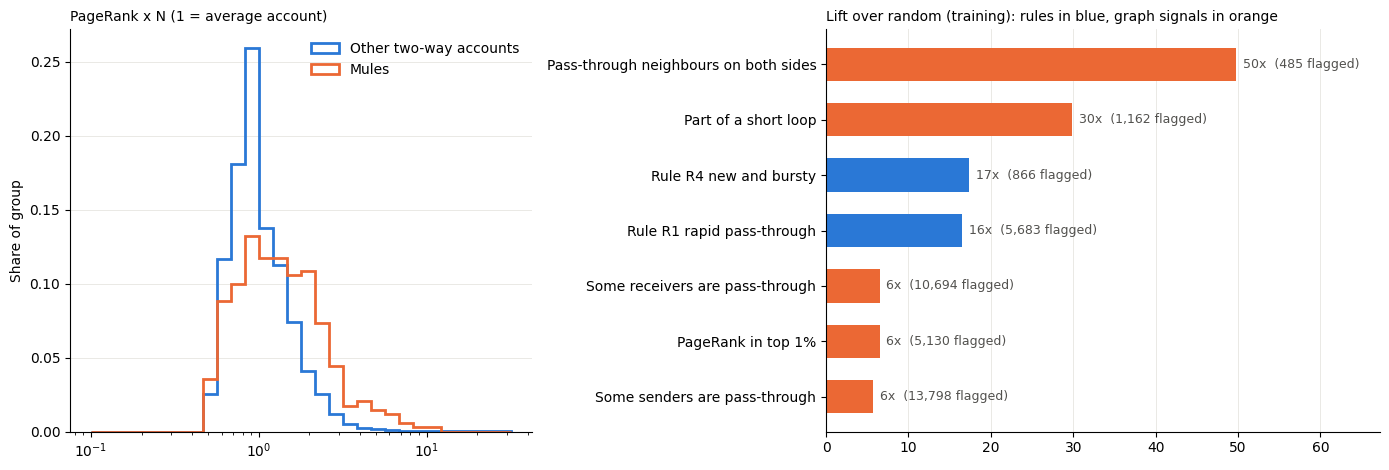

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.2]})

# Left: PageRank, log scale because it spans orders of magnitude
ax = axes[0]
bins = np.logspace(-1, 1.5, 31)
for mask, colour, label in [((group == "clean_two_way"), "#2a78d6", "Other two-way accounts"), ((group == "mule"), "#eb6834", "Mules")]:
    vals = d.pagerank_scaled[mask].clip(bins[0], bins[-1])
    ax.hist(vals, bins=bins, weights=np.full(len(vals), 1 / len(vals)), histtype="step", linewidth=2, color=colour, label=label)
ax.set_xscale("log")
ax.set_title("PageRank x N (1 = average account)", loc="left", fontsize=10)
ax.set_ylabel("Share of group")
ax.legend(frameon=False)

# Right: lift of each signal, one series so one colour; values labelled
ax = axes[1]
t = lift_table.sort_values("lift")
colours = ["#eb6834" if s.startswith(("Part of", "Pass-through neighbours", "Some", "PageRank")) else "#2a78d6" for s in t.signal]
ax.barh(t.signal, t.lift, color=colours, height=0.6)
for y, (lift, n) in enumerate(zip(t.lift, t.flagged)):
    ax.text(lift + 0.8, y, f"{lift:.0f}x  ({n:,} flagged)", va="center", fontsize=9, color="#52514e")
ax.set_title("Lift over random (training): rules in blue, graph signals in orange", loc="left", fontsize=10)
ax.set_xlim(0, t.lift.max() * 1.35)
for a in axes:
    a.spines[["top", "right"]].set_visible(False)
    a.grid(axis="x" if a is axes[1] else "y", color="#e6e5e1", linewidth=0.6)
    a.set_axisbelow(True)
fig.tight_layout()
fig.savefig("reports/figures/03_graph_signals.png", dpi=150)
plt.show()

## 5. Findings (training window)
- **Short loops** are the strongest single signal found so far: about 30x lift, against about 17x for the best rule. Few accounts have one, so recall is low.
- **Pass-through neighbours on both sides** (money arrives from, and leaves to, mule-like accounts) is sharper still at about 50x lift, but covers only a small slice of mules. This is the "chain" idea made measurable.
- **PageRank** separates only mildly: mules sit somewhat above other two-way accounts.
- In/out/weighted degree were verified to equal Phase 2's fan-in, fan-out and USD totals, so they were not duplicated.
- The loop search covered the R1-R4-flagged accounts plus neighbours (excluding 39 hubs) and took seconds, so the time box was never needed.
- **Limitation:** loops are capped at 4 hops inside one window. Longer or multi-day laundering cycles cannot be found this way; Phase 5 typology recall will show how much that matters.